In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2: Import libraries
import os
import pandas as pd
import io
# Step 3: Set path to folder containing .txt files

folder_path = "/content/drive/MyDrive/PrecisonOncology/ov_tcga/ov_tcga/"

In [ ]:
mut = pd.read_csv("/content/drive/MyDrive/PrecisonOncology/ov_tcga/ov_tcga/data_mutations.txt", sep="\t", low_memory=False)
mut.head(5)

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,ref_allele,context,gene,classification,chr,tum_allele1,tum_allele2,end,start,dataset
0,HRNR,388697.0,broad.mit.edu,GRCh37,1,152193357,152193357,+,missense_variant,Missense_Mutation,...,C,21,HRNR,SNP,1,C,T,150459981,150459981,Broad
1,LHX9,56956.0,broad.mit.edu,GRCh37,1,197887048,197887048,+,missense_variant,Missense_Mutation,...,G,42,LHX9,SNP,1,G,T,196153671,196153671,Broad
2,PPP2R5A,5525.0,broad.mit.edu,GRCh37,1,212530010,212530010,+,missense_variant,Missense_Mutation,...,C,29,PPP2R5A,SNP,1,C,A,210596633,210596633,Broad
3,ZP4,57829.0,broad.mit.edu,GRCh37,1,238051678,238051678,+,missense_variant,Missense_Mutation,...,G,41,ZP4,SNP,1,G,A,236118301,236118301,Broad
4,NKX2-3,159296.0,broad.mit.edu,GRCh37,10,101292917,101292917,+,missense_variant,Missense_Mutation,...,C,18,NKX2-3,SNP,10,C,T,101282907,101282907,Broad


In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/PrecisonOncology/ov_tcga_clinical_data.tsv', sep='\t',engine='python')
df2.head(5)

,Study ID,Patient ID,Sample ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Cancer Type,Cancer Type Detailed,Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage,Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage,...,Stage Other,Time between clamping and freezing,Time between excision and freezing,Tissue Source Site,TMB (nonsynonymous),Primary Therapy Outcome Success Type,Person Neoplasm Status,Tumor Disease Anatomic Site,Vascular invasion indicator,Vial number
0,ov_tcga,TCGA-04-1331,TCGA-04-1331-01,78.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,4,2.600000,NaN,WITH TUMOR,Ovary,NO,A
1,ov_tcga,TCGA-04-1332,TCGA-04-1332-01,70.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,4,0.800000,NaN,WITH TUMOR,Ovary,NaN,A
2,ov_tcga,TCGA-04-1335,TCGA-04-1335-01,60.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,4,NaN,NaN,WITH TUMOR,Ovary,NO,A
3,ov_tcga,TCGA-04-1336,TCGA-04-1336-01,55.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,4,1.700000,NaN,TUMOR FREE,Ovary,NaN,A
4,ov_tcga,TCGA-04-1337,TCGA-04-1337-01,78.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,4,2.766667,NaN,WITH TUMOR,Ovary,NaN,A


In [ ]:
print("mut columns:\n" ,mut.columns)
print("df2 columns:\n", df2.columns)

mut columns:
 Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS',
       'dbSNP_Val_Status', 'Tumor_Sample_Barcode',
       'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1',
       'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1',
       'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1',
       'Match_Norm_Validation_Allele2', 'Verification_Status',
       'Validation_Status', 'Mutation_Status', 'Sequencing_Phase',
       'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File',
       'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count',
       'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq',
       'Protein_position', 'Codons', 'Hotspot', 'type', 'ref_allele',
       'context', 'gene', 'classification', 'chr', 't

In [ ]:
# Only keep Sample ID and Gene, and clean
mutation_df = mut[['Tumor_Sample_Barcode', 'Hugo_Symbol']].dropna()
mutation_df = mutation_df.rename(columns={
    'Tumor_Sample_Barcode': 'Sample ID',
    'Hugo_Symbol': 'Gene'
})


In [ ]:
# Create 0/1 matrix: rows = Sample ID, columns = Genes
mutation_matrix = mutation_df.assign(Mutated=1).pivot_table(
    index='Sample ID',
    columns='Gene',
    values='Mutated',
    fill_value=0
).reset_index()

In [ ]:
# Merge on 'Sample ID', preserving all columns from df2
df3 = pd.merge(df2, mutation_matrix, on='Sample ID', how='left')
print("✅ Merged shape:", df3.shape)


✅ Merged shape: (617, 10128)


In [ ]:
df3.head(5)

,Study ID,Patient ID,Sample ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Cancer Type,Cancer Type Detailed,Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage,Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage,...,ZWILCH,ZXDA,ZXDB,ZXDC,ZYG11B,ZZEF1,ZZZ3,hsa-mir-7162,uc003vym.2,uc003vyo.2
0,ov_tcga,TCGA-04-1331,TCGA-04-1331-01,78.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ov_tcga,TCGA-04-1332,TCGA-04-1332-01,70.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ov_tcga,TCGA-04-1335,TCGA-04-1335-01,60.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ov_tcga,TCGA-04-1336,TCGA-04-1336-01,55.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ov_tcga,TCGA-04-1337,TCGA-04-1337-01,78.0,NaN,NaN,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("df3 columns:\n", df3.columns)

df3 columns:
 Index(['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age',
       'Neoplasm Disease Stage American Joint Committee on Cancer Code',
       'American Joint Committee on Cancer Publication Version Type',
       'Cancer Type', 'Cancer Type Detailed',
       'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage',
       'Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage',
       ...
       'ZWILCH', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11B', 'ZZEF1', 'ZZZ3',
       'hsa-mir-7162', 'uc003vym.2', 'uc003vyo.2'],
      dtype='object', length=10128)


In [ ]:
df3.info()
df3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Columns: 10128 entries, Study ID to uc003vyo.2
dtypes: float64(10080), int64(2), object(46)
memory usage: 47.7+ MB


,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage,Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage,Neoplasm American Joint Committee on Cancer Clinical Primary Tumor T Stage,Days to Sample Collection.,Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value,days_to_patient_progression_free,Days to Sample Procurement,...,ZWILCH,ZXDA,ZXDB,ZXDC,ZYG11B,ZZEF1,ZZZ3,hsa-mir-7162,uc003vym.2,uc003vyo.2
count,604.000000,0.0,0.0,0.0,0.0,0.0,10.000000,604.0,0.0,0.0,...,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000
mean,59.625828,NaN,NaN,NaN,NaN,NaN,489.200000,0.0,NaN,NaN,...,0.003165,0.006329,0.006329,0.003165,0.003165,0.006329,0.012658,0.006329,0.003165,0.003165
std,11.474063,NaN,NaN,NaN,NaN,NaN,457.927408,0.0,NaN,NaN,...,0.056254,0.079429,0.079429,0.056254,0.056254,0.079429,0.111972,0.079429,0.056254,0.056254
min,26.000000,NaN,NaN,NaN,NaN,NaN,11.000000,0.0,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,NaN,NaN,NaN,NaN,NaN,120.500000,0.0,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.000000,NaN,NaN,NaN,NaN,NaN,320.500000,0.0,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,68.000000,NaN,NaN,NaN,NaN,NaN,779.500000,0.0,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,NaN,NaN,NaN,NaN,NaN,1211.000000,0.0,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df3.count()

,0
Study ID,617
Patient ID,617
Sample ID,617
Diagnosis Age,604
Neoplasm Disease Stage American Joint Committee on Cancer Code,0
...,...
ZZEF1,316
ZZZ3,316
hsa-mir-7162,316
uc003vym.2,316


In [ ]:
gene_cols = [col for col in df3.columns if col.upper() in ['FOXM1', 'TP53', 'TTN']]
print("Found gene columns:", gene_cols)

Found gene columns: ['TP53', 'TTN']


In [ ]:
# Mutation data is sparse; fill NaNs with 0 to indicate 'no mutation'
df3.loc[:, df3.columns.difference(df2.columns)] = df3.loc[:, df3.columns.difference(df2.columns)].fillna(0)

In [ ]:
# Convert all column names to uppercase for safe comparison
df3.columns = df3.columns.map(str)  # Ensure all are strings
upper_cols = [col.upper() for col in df3.columns]

# List of key genes to check
genes_of_interest = ['FOXM1', 'TP53', 'TTN']

# Find matching columns (case-insensitive)
gene_cols = [df3.columns[i] for i, col in enumerate(upper_cols) if col in genes_of_interest]

print("Found gene columns:", gene_cols)


Found gene columns: ['TP53', 'TTN']


In [ ]:
import plotly.graph_objects as go

# TP53 survival groups
tp53_mut = df3[df3['TP53'] == 1]['Overall Survival (Months)']
tp53_wt = df3[df3['TP53'] == 0]['Overall Survival (Months)']

# Create the histogram
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=tp53_mut,
    name='TP53 Mutated',
    opacity=0.75,
    marker_color='crimson'
))

fig.add_trace(go.Histogram(
    x=tp53_wt,
    name='TP53 Wild-Type',
    opacity=0.75,
    marker_color='steelblue'
))

# Overlay both histograms
fig.update_layout(
    barmode='overlay',
    title='Survival by TP53 Mutation',
    xaxis_title='Overall Survival (Months)',
    yaxis_title='Patient Count',
    legend=dict(x=0.7, y=0.95)
)

fig.show()


In [ ]:
import plotly.graph_objects as go

# Split survival data based on TTN mutation
ttn_mut = df3[df3['TTN'] == 1]['Overall Survival (Months)']
ttn_wt = df3[df3['TTN'] == 0]['Overall Survival (Months)']

# Create the histogram
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=ttn_mut,
    name='TTN Mutated',
    opacity=0.75,
    marker_color='darkorange'
))

fig.add_trace(go.Histogram(
    x=ttn_wt,
    name='TTN Wild-Type',
    opacity=0.75,
    marker_color='seagreen'
))

# Overlay both histograms
fig.update_layout(
    barmode='overlay',
    title='Survival by TTN Mutation Status',
    xaxis_title='Overall Survival (Months)',
    yaxis_title='Patient Count',
    legend=dict(x=0.7, y=0.95)
)

fig.show()


In [ ]:
import pandas as pd
import scipy.stats as stats

# Create age group column for Chi-squared test
df3['Age Group'] = df3['Diagnosis Age'].apply(lambda x: 'Under 64' if x < 64 else '64 or Above')

# Contingency table for Age vs Survival Status
age_survival_table = pd.crosstab(df3['Age Group'], df3['Overall Survival Status'])

# Perform Chi-squared test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(age_survival_table)

print(f"Chi-Squared Test for Age Group vs Survival Status")
print(f"Chi-squared Statistic: {chi2_stat}")
print(f"P-Value: {p_val}")


Chi-Squared Test for Age Group vs Survival Status
Chi-squared Statistic: 5.932053042295691
P-Value: 0.014867910303306899


In [ ]:
# Contingency table for Race vs Survival Status
race_survival_table = pd.crosstab(df3['Race Category'], df3['Overall Survival Status'])

# Perform Chi-squared test
chi2_stat_race, p_val_race, dof_race, expected_race = stats.chi2_contingency(race_survival_table)

print(f"Chi-Squared Test for Race Category vs Survival Status")
print(f"Chi-squared Statistic: {chi2_stat_race}")
print(f"P-Value: {p_val_race}")


Chi-Squared Test for Race Category vs Survival Status
Chi-squared Statistic: 12.66550660011144
P-Value: 0.013031285523788327


In [ ]:
import scipy.stats as stats

# Create a column to represent age group (Under 64 vs 64 or Above)
df3['Age Group'] = df3['Diagnosis Age'].apply(lambda x: 'Under 64' if x < 64 else '64 or Above')

# Separate the survival data for the two age groups
under_64 = df3[df3['Age Group'] == 'Under 64']['Overall Survival Status'].map({'LIVING': 1, 'DECEASED': 0})
over_64 = df3[df3['Age Group'] == '64 or Above']['Overall Survival Status'].map({'LIVING': 1, 'DECEASED': 0})

# Perform Mann-Whitney U test to compare survival between under 64 and over 64 groups
u_stat, p_val = stats.mannwhitneyu(under_64, over_64)

print(f"Mann-Whitney U test result:")
print(f"U-Statistic: {u_stat}")
print(f"P-Value: {p_val}")


Mann-Whitney U test result:
U-Statistic: nan
P-Value: nan


Expected Output:
This test will give you the Chi-squared statistic, P-value, and expected frequencies based on the null hypothesis. The P-value will tell us if there's a significant relationship between race category and survival status.

Interpretation of Results:
If the P-value is less than 0.05, there is a significant association between race category and survival status.

If the P-value is greater than 0.05, we fail to reject the null hypothesis, meaning there's no significant relationship.

In [ ]:
# Cross-tabulation between Race Category and Survival Status
race_survival_table = pd.crosstab(df3['Race Category'], df3['Overall Survival Status'])

# Perform the Chi-Squared test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(race_survival_table)

print(f"Chi-Squared Statistic: {chi2_stat}")
print(f"P-Value: {p_val}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies: {expected}")


Chi-Squared Statistic: 12.66550660011144
P-Value: 0.013031285523788327
Degrees of Freedom: 4
Expected Frequencies: [[  1.14136126   1.85863874]
 [  7.9895288   13.0104712 ]
 [ 12.93542757  21.06457243]
 [  0.38045375   0.61954625]
 [195.55322862 318.44677138]]


The P-value (0.013) is less than 0.05, which indicates a statistically significant relationship between race category and survival status. This means that the survival rates differ significantly across different race categories in this dataset.

The Chi-Squared statistic (12.67) further supports the idea that race plays a significant role in predicting survival status, given the number of cases and the expected frequencies.

The Degrees of Freedom (4) represent the number of categories minus one for each variable involved in the test, as expected in a chi-squared distribution for a contingency table.

In [ ]:
# Check the unique values in the "Overall Survival Status" column
print(df3['Overall Survival Status'].unique())


['1:DECEASED' '0:LIVING' nan]


In [ ]:
# Clean the 'Overall Survival Status' column
df3['Overall Survival Status'] = df3['Overall Survival Status'].replace({'1:DECEASED': 'DECEASED', '0:LIVING': 'LIVING'})

# Now proceed with the analysis
race_survival_table = pd.crosstab(df3['Race Category'], df3['Overall Survival Status'])
from scipy.stats import chi2_contingency
# Perform Chi-Squared Test
chi2_stat, p_val, dof, ex = chi2_contingency(race_survival_table)

# Output the results
print("Chi-Squared Statistic:", chi2_stat)
print("P-Value:", p_val)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:", ex)


Chi-Squared Statistic: 12.66550660011144
P-Value: 0.013031285523788327
Degrees of Freedom: 4
Expected Frequencies: [[  1.85863874   1.14136126]
 [ 13.0104712    7.9895288 ]
 [ 21.06457243  12.93542757]
 [  0.61954625   0.38045375]
 [318.44677138 195.55322862]]


The Chi-Squared test results indicate the following:

Chi-Squared Statistic: 12.67

P-Value: 0.013

Degrees of Freedom: 4

Expected Frequencies: These represent the expected count of patients in each race and survival group under the assumption that race and survival status are independent.

The P-value of 0.013 suggests that there is a statistically significant relationship between race and survival status, since the value is less than the common significance level of 0.05. This implies that survival outcomes are likely influenced by the race category.


In [ ]:
# Calculate survival rate for each race category
for race, counts in race_survival_table.iterrows():
    total = sum(counts)
    survival_rate = (counts['LIVING'] / total) * 100
    print(f"Survival rate for {race}: {survival_rate:.2f}%")


Survival rate for AMERICAN INDIAN OR ALASKA NATIVE: 0.00%
Survival rate for ASIAN: 71.43%
Survival rate for BLACK OR AFRICAN AMERICAN: 35.29%
Survival rate for NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER: 0.00%
Survival rate for WHITE: 37.16%


In [ ]:
import plotly.graph_objects as go

# Data for the race categories and survival rates
race_categories = ['AMERICAN INDIAN OR ALASKA NATIVE', 'ASIAN', 'BLACK OR AFRICAN AMERICAN', 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'WHITE']
survival_rates = [0.00, 71.43, 35.29, 0.00, 37.16]

# Create the bar chart using Plotly
fig = go.Figure(data=[go.Bar(
    x=race_categories,
    y=survival_rates,
    text=survival_rates,
    textposition='auto',  # Display the values on top of the bars
    marker=dict(color='royalblue'),
)])

# Add title and labels
fig.update_layout(
    title="Survival Rates by Race Category",
    xaxis_title="Race Category",
    yaxis_title="Survival Rate (%)",
    template="plotly_dark"  # Optional: you can choose other templates as well
)

# Show the plot
fig.show()


Highest Survival Rate: The Asian group has the highest survival rate (71.43%), which suggests that patients in this group have a higher likelihood of surviving.

Lowest Survival Rates: Both the AMERICAN INDIAN OR ALASKA NATIVE and NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER groups show a 0% survival rate, which suggests no patients in these categories survived the condition in the dataset.

Middle Range Survival: The BLACK OR AFRICAN AMERICAN and WHITE categories have survival rates of 35.29% and 37.16% respectively, indicating moderate survival compared to the Asian group but lower than expected.

Interpretation and Context:
These survival rate disparities could reflect a range of factors such as genetic factors, socioeconomic status, access to healthcare, or comorbidities that may vary by racial group.

It is also important to note that the AMERICAN INDIAN OR ALASKA NATIVE and NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER categories have very small sample sizes in your dataset (and especially the Native Hawaiian group has just one sample), which could skew the results, making it less reliable to draw conclusions based solely on these groups.

In [ ]:
import pandas as pd

# Assuming df_cleaned is your dataframe after dropping critical rows (like survival data)
df3 = df3.copy()

# For numerical columns (e.g., Age, Gene Expression values), we use median or mean imputation
numerical_cols = df3.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    # If the column has missing values, impute them with median or mean (depending on distribution)
    if df3[col].isnull().sum() > 0:
        df3[col] = df3[col].fillna(df3[col].median())  # Use median for robustness to outliers
        # Alternatively, you could use mean:
        # df[col] = df[col].fillna(df[col].mean())

# For categorical columns (e.g., mutation status, race), we use mode imputation
categorical_cols = df3.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df3[col].isnull().sum() > 0:
        # Impute missing values with the most frequent value (mode)
        df3[col] = df3[col].fillna(df3[col].mode()[0])

# Check the result of imputation
print(df3.isnull().sum())


Study ID                                                            0
Patient ID                                                          0
Sample ID                                                           0
Diagnosis Age                                                       0
Neoplasm Disease Stage American Joint Committee on Cancer Code    617
                                                                 ... 
ZZZ3                                                                0
hsa-mir-7162                                                        0
uc003vym.2                                                          0
uc003vyo.2                                                          0
Age Group                                                           0
Length: 10129, dtype: int64


<ipython-input-27-3709744b0375>:22: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
# Drop the columns with all missing values (like 'Neoplasm Disease Stage' column)
df_cleaned = df3.drop(columns=['Neoplasm Disease Stage American Joint Committee on Cancer Code'])

# Now, proceed with imputing missing values for the rest of the columns
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Impute missing values in numerical columns using median or mean
for col in numerical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  # Use median

# For categorical columns, use mode for imputation
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])  # Use mode

# Check if there are any remaining missing values
print(df_cleaned.isnull().sum())


Study ID                                                         0
Patient ID                                                       0
Sample ID                                                        0
Diagnosis Age                                                    0
American Joint Committee on Cancer Publication Version Type    617
                                                              ... 
ZZZ3                                                             0
hsa-mir-7162                                                     0
uc003vym.2                                                       0
uc003vyo.2                                                       0
Age Group                                                        0
Length: 10128, dtype: int64


In [ ]:
# Impute missing values in categorical columns with mode (if not already done)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:  # Check if there are missing values
        mode_value = df_cleaned[col].mode()[0]  # Find the mode
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)  # Fill with the mode

# Check for any remaining missing values
print(df_cleaned.isnull().sum())


Study ID                                                         0
Patient ID                                                       0
Sample ID                                                        0
Diagnosis Age                                                    0
American Joint Committee on Cancer Publication Version Type    617
                                                              ... 
ZZZ3                                                             0
hsa-mir-7162                                                     0
uc003vym.2                                                       0
uc003vyo.2                                                       0
Age Group                                                        0
Length: 10128, dtype: int64


In [ ]:
# Impute missing values in numeric columns with the mean
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    if df_cleaned[col].isnull().sum() > 0:  # Check if there are missing values
        mean_value = df_cleaned[col].mean()  # Calculate the mean
        df_cleaned[col] = df_cleaned[col].fillna(mean_value)  # Fill with the mean

# Check for any remaining missing values
print(df_cleaned.isnull().sum())


Study ID                                                         0
Patient ID                                                       0
Sample ID                                                        0
Diagnosis Age                                                    0
American Joint Committee on Cancer Publication Version Type    617
                                                              ... 
ZZZ3                                                             0
hsa-mir-7162                                                     0
uc003vym.2                                                       0
uc003vyo.2                                                       0
Age Group                                                        0
Length: 10128, dtype: int64


In [ ]:
# Drop columns with all missing values
df_cleaned = df3.dropna(axis=1, how='all')

# Check the new count of missing values in each column
print(df_cleaned.isnull().sum())


Study ID         0
Patient ID       0
Sample ID        0
Diagnosis Age    0
Cancer Type      0
                ..
ZZZ3             0
hsa-mir-7162     0
uc003vym.2       0
uc003vyo.2       0
Age Group        0
Length: 10107, dtype: int64


In [ ]:
# Impute missing values in categorical columns with mode
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:  # Check if there are missing values
        mode_value = df_cleaned[col].mode()[0]  # Find the mode
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)  # Fill with the mode

# Check for any remaining missing values
print(df_cleaned.isnull().sum())


Study ID         0
Patient ID       0
Sample ID        0
Diagnosis Age    0
Cancer Type      0
                ..
ZZZ3             0
hsa-mir-7162     0
uc003vym.2       0
uc003vyo.2       0
Age Group        0
Length: 10107, dtype: int64


In [ ]:
# Chi-squared test for TP53 mutation vs. Overall Survival Status
tp53_survival_table = pd.crosstab(df_cleaned['TP53'], df_cleaned['Overall Survival Status'])

# Perform Chi-squared test
chi2_tp53, p_tp53, dof_tp53, expected_tp53 = stats.chi2_contingency(tp53_survival_table)

# Display results
print(f"Chi-Squared Statistic for TP53: {chi2_tp53}")
print(f"P-Value for TP53: {p_tp53}")
print(f"Degrees of Freedom for TP53: {dof_tp53}")
print(f"Expected Frequencies for TP53: \n{expected_tp53}")


Chi-Squared Statistic for TP53: 5.761100119937094
P-Value for TP53: 0.016384809882998893
Degrees of Freedom for TP53: 1
Expected Frequencies for TP53: 
[[205.97730956 132.02269044]
 [170.02269044 108.97730956]]


In [ ]:
# Chi-squared test for TTN mutation vs. Overall Survival Status
ttn_survival_table = pd.crosstab(df_cleaned['TTN'], df_cleaned['Overall Survival Status'])

# Perform Chi-squared test
chi2_ttn, p_ttn, dof_ttn, expected_ttn = stats.chi2_contingency(ttn_survival_table)

# Display results
print(f"Chi-Squared Statistic for TTN: {chi2_ttn}")
print(f"P-Value for TTN: {p_ttn}")
print(f"Degrees of Freedom for TTN: {dof_ttn}")
print(f"Expected Frequencies for TTN: \n{expected_ttn}")


Chi-Squared Statistic for TTN: 3.1690456658212796
P-Value for TTN: 0.07504628531492963
Degrees of Freedom for TTN: 1
Expected Frequencies for TTN: 
[[333.34197731 213.65802269]
 [ 42.65802269  27.34197731]]


In [ ]:
import plotly.graph_objects as go

# TP53 results (observed vs expected)
tp53_observed = [205.98, 170.02]  # Living, Deceased for no mutation
tp53_expected = [132.02, 108.98]  # Living, Deceased for mutation

# TTN results (observed vs expected)
ttn_observed = [333.34, 42.66]  # Living, Deceased for no mutation
ttn_expected = [213.66, 27.34]  # Living, Deceased for mutation

# Plot for TP53
tp53_fig = go.Figure()

# Adding observed bars for TP53
tp53_fig.add_trace(go.Bar(
    x=["Living", "Deceased"],
    y=tp53_observed,
    name="Observed (TP53)",
    marker_color='blue'
))

# Adding expected bars for TP53
tp53_fig.add_trace(go.Bar(
    x=["Living", "Deceased"],
    y=tp53_expected,
    name="Expected (TP53)",
    marker_color='orange'
))

# Layout for TP53
tp53_fig.update_layout(
    title="Chi-Squared Test Results for TP53 Mutation vs Survival Status",
    xaxis_title="Survival Status",
    yaxis_title="Frequency",
    barmode='group',
    showlegend=True
)

# Plot for TTN
ttn_fig = go.Figure()

# Adding observed bars for TTN
ttn_fig.add_trace(go.Bar(
    x=["Living", "Deceased"],
    y=ttn_observed,
    name="Observed (TTN)",
    marker_color='green'
))

# Adding expected bars for TTN
ttn_fig.add_trace(go.Bar(
    x=["Living", "Deceased"],
    y=ttn_expected,
    name="Expected (TTN)",
    marker_color='red'
))

# Layout for TTN
ttn_fig.update_layout(
    title="Chi-Squared Test Results for TTN Mutation vs Survival Status",
    xaxis_title="Survival Status",
    yaxis_title="Frequency",
    barmode='group',
    showlegend=True
)

# Show both plots
tp53_fig.show()
ttn_fig.show()


In [ ]:
df_cleaned.info()
df_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Columns: 10107 entries, Study ID to Age Group
dtypes: bool(1), float64(10058), int64(2), object(46)
memory usage: 47.6+ MB


,Diagnosis Age,Days to Sample Collection.,Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value,Disease Free (Months),Performance Status,Fraction Genome Altered,Year Cancer Initial Diagnosis,Karnofsky Performance Score,Longest Dimension,Mutation Count,...,ZWILCH,ZXDA,ZXDB,ZXDC,ZYG11B,ZZEF1,ZZZ3,hsa-mir-7162,uc003vym.2,uc003vyo.2
count,617.000000,617.000000,617.0,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,...,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000
mean,59.612642,323.234198,0.0,20.224400,0.110211,0.554534,2003.735818,79.432739,1.376499,46.069692,...,0.001621,0.003241,0.003241,0.001621,0.001621,0.003241,0.006483,0.003241,0.001621,0.001621
std,11.352700,59.315110,0.0,19.985466,0.434894,0.182997,4.053205,5.238075,0.584221,19.817348,...,0.040258,0.056888,0.056888,0.040258,0.040258,0.056888,0.080321,0.056888,0.040258,0.040258
min,26.000000,11.000000,0.0,0.530000,0.000000,0.000000,1992.000000,40.000000,0.300000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,320.500000,0.0,10.020000,0.000000,0.429000,2001.000000,80.000000,1.000000,42.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.000000,320.500000,0.0,14.765000,0.000000,0.568500,2004.000000,80.000000,1.300000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,68.000000,320.500000,0.0,21.880000,0.000000,0.666900,2007.000000,80.000000,1.500000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,1211.000000,0.0,180.060000,4.000000,1.000000,2013.000000,100.000000,8.000000,158.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_cleaned.count()

,0
Study ID,617
Patient ID,617
Sample ID,617
Diagnosis Age,617
Cancer Type,617
...,...
ZZZ3,617
hsa-mir-7162,617
uc003vym.2,617
uc003vyo.2,617


# Why XGBoost Is Suitable for this Data
| Reason                               | Explanation                                                                                               |
| ------------------------------------ | --------------------------------------------------------------------------------------------------------- |
| **Handles High-Dimensional Data**    | XGBoost is robust even with thousands of features — especially sparse or binary ones like gene mutations. |
| **Captures Non-Linear Interactions** | It can model complex interactions (e.g., TP53 + TTN + clinical variables) better than linear models.      |
| **Built-in Feature Selection**       | It automatically reduces the impact of irrelevant features by assigning low importance.                   |
| **Handles Missing Values**           | XGBoost natively manages missing data during training.                                                    |
| **Scalable and Fast**                | Despite the size, XGBoost is optimized for speed and efficiency.                                          |
| **Model Explainability (SHAP)**      | Tools like SHAP let you interpret predictions even in complex models like XGBoost.                        |


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import shap
import plotly.express as px

# ---- STEP 1: Prepare Features and Target ----
df_cleaned = df_cleaned.copy()
df_cleaned.loc[:, 'Survival_Binary'] = df_cleaned['Overall Survival Status'].map({'LIVING': 1, 'DECEASED': 0})

# Drop non-informative or identifier columns
X = df_cleaned.drop(columns=[
    'Study ID', 'Patient ID', 'Sample ID',
    'Overall Survival Status', 'Survival_Binary'
])

# Convert categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Handle any NaN values by replacing them with the median of the column
X = X.fillna(X.median())

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Check for boolean columns and convert to integers (0 and 1)
bool_columns = X.select_dtypes(include=['bool']).columns
if len(bool_columns) > 0:
    print(f"Converting boolean columns to integers: {bool_columns}")
    X[bool_columns] = X[bool_columns].astype(int)

# Ensure no NaN values in X
X = X.fillna(0)

# Confirm all columns are now numeric
assert X.select_dtypes(include=['object']).shape[1] == 0, "There are still non-numeric columns in the data"

# Split data into train and test sets
y = df_cleaned['Survival_Binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- STEP 2: Check data types for X_train and X_test ----
print("Data types in X_train:")
print(X_train.dtypes)

# ---- STEP 3: Train XGBoost ----
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

# ---- STEP 4: Evaluate ----
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ---- STEP 5: Check SHAP Explainer with X_train ----
# Create a SHAP explainer for XGBoost model
try:
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)
except Exception as e:
    print(f"Error during SHAP explainer: {e}")
    # Print the types of the columns to check for any unexpected types
    print("X_train column types:")
    print(X_train.dtypes)

# If SHAP explainer works, we continue
if 'shap_values' in locals():
    shap_df = pd.DataFrame(shap_values.values, columns=X.columns)

    # Mean absolute SHAP values per feature
    mean_shap = shap_df.abs().mean().sort_values(ascending=False).head(30)

    # Plot in Plotly
    fig = px.bar(
        x=mean_shap.values[::-1],
        y=mean_shap.index[::-1],
        orientation='h',
        title='Top 30 Feature Importances (SHAP)',
        labels={'x': 'Mean |SHAP value|', 'y': 'Feature'}
    )
    fig.show()


Converting boolean columns to integers: Index(['Oct embedded',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IB',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IC',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIA',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIB',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIC',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIIA',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIIB',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IIIC',
       'Neoplasm American Joint Committee on Cancer Clinical Group Stage_Stage IV',
       ...
       'Primary Therapy Outcome Success Type_Partial Remission/Response',
       'Primary Therapy Outcome Success Type_Progressive Disease',
       'Person Neopl

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.25, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

xgb_base = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

rs = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=5, verbose=1, random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)

print("Best parameters:", rs.best_params_)

# Use the best estimator
model = rs.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[15:30:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Best parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.25, 'colsample_bytree': 0.8}


In [ ]:
# prompt: save tsv file df_cleaned

df_cleaned.to_csv('/content/drive/MyDrive/PrecisonOncology/ov_tcga/df_cleaned.tsv', sep='\t', index=False)

In [ ]:
features = X.columns.tolist()


In [ ]:
gene_features = [f for f in features if 'gene' in f.lower() or 'mutation' in f.lower() or 'expression' in f.lower()]
non_gene_features = [f for f in features if f not in gene_features]
shap_df = pd.DataFrame(shap_values.values, columns=X.columns)

mean_shap = shap_df.abs().mean()

# Aggregate by category
gene_shap_importance = mean_shap[gene_features].sum()
non_gene_shap_importance = mean_shap[non_gene_features].sum()

print(f"Total SHAP contribution of gene features: {gene_shap_importance:.4f}")
print(f"Total SHAP contribution of non-gene features: {non_gene_shap_importance:.4f}")
# Print the feature lists
print(" Gene-related features:")
for f in gene_features:
    print(" -", f)

print("\n Non-gene (clinical/environmental) features:")
for f in non_gene_features:
    print(" -", f)

Total SHAP contribution of gene features: 0.1265
Total SHAP contribution of non-gene features: 9.5868
 Gene-related features:
 - Mutation Count

 Non-gene (clinical/environmental) features:
 - Diagnosis Age
 - Days to Sample Collection.
 - Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value
 - Disease Free (Months)
 - Performance Status
 - Fraction Genome Altered
 - Year Cancer Initial Diagnosis
 - Karnofsky Performance Score
 - Longest Dimension
 - Oct embedded
 - Overall Survival (Months)
 - Number of Samples Per Patient
 - Sample Initial Weight
 - Sample type id
 - Shortest Dimension
 - Specimen Second Longest Dimension
 - TMB (nonsynonymous)
 - A1CF
 - A2M
 - A2ML1
 - AAAS
 - AACS
 - AADACL4
 - AAED1
 - AAMP
 - AARS
 - AARS2
 - AASDH
 - AASDHPPT
 - AASS
 - AATF
 - AATK
 - ABCA1
 - ABCA10
 - ABCA12
 - ABCA13
 - ABCA3
 - ABCA4
 - ABCA5
 - ABCA6
 - ABCA7
 - ABCA8
 - ABCA9
 - ABCB1
 - ABCB11
 - ABCB4
 - ABCB5
 - ABCB6
 - ABCB7
 - ABCB8
 - ABCB9
 - ABCC1
 - ABCC10
 - 

Gene-related features contributed only ~1.3% of the total SHAP importance:

0.1265 / (0.1265 + 9.5868) ≈ 1.3%

Non-gene features dominated the model's predictions, contributing over 98% of the decision-making power.



In [ ]:
# Already done earlier
model = rs.best_estimator_

# Evaluate on test data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC Curve (AUC = {roc_auc:.2f})', line=dict(color='darkorange')))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Guess', line=dict(dash='dash', color='navy')))
fig_roc.update_layout(
    title='Receiver Operating Characteristic (ROC)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    showlegend=True,
    width=600,
    height=500
)
fig_roc.show()


In [ ]:
import plotly.express as px
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
labels = ['Deceased', 'Living']

# Convert to DataFrame for heatmap
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

fig_cm = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale='Blues',
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    title="Confusion Matrix"
)
fig_cm.update_layout(width=500, height=500)
fig_cm.show()

In [ ]:
#import joblib
#joblib.dump(model, "xgb_best_model.joblib")


# NEW - Use this instead
model.get_booster().save_model("xgb_best_model.json")


In [ ]:
input_features = X.columns.tolist()  # assuming X is the dataset used for model training

In [ ]:
X.head(5)

,Diagnosis Age,Days to Sample Collection.,Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value,Disease Free (Months),Performance Status,Fraction Genome Altered,Year Cancer Initial Diagnosis,Karnofsky Performance Score,Longest Dimension,Mutation Count,...,Primary Therapy Outcome Success Type_Partial Remission/Response,Primary Therapy Outcome Success Type_Progressive Disease,Person Neoplasm Status_WITH TUMOR,Tumor Disease Anatomic Site_Ovary,Tumor Disease Anatomic Site_Peritoneum ovary,Vascular invasion indicator_YES,Vial number_B,Vial number_C,Vial number_D,Age Group_Under 64
0,78.0,320.5,0.0,15.080,0.0,0.4372,2004.0,80.0,0.5,78.0,...,0,0,1,1,0,0,0,0,0,0
1,70.0,320.5,0.0,12.910,1.0,0.3714,2002.0,80.0,1.0,23.0,...,0,0,1,1,0,1,0,0,0,0
2,60.0,320.5,0.0,14.765,0.0,0.3906,2005.0,80.0,1.5,43.0,...,0,0,1,1,0,0,0,0,0,1
3,55.0,320.5,0.0,49.110,0.0,0.5233,2005.0,80.0,1.0,51.0,...,0,0,0,1,0,1,0,0,0,1
4,78.0,320.5,0.0,14.765,1.0,0.3287,2005.0,80.0,1.2,85.0,...,0,0,1,1,0,1,0,0,0,0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Columns: 12577 entries, Diagnosis Age to Age Group_Under 64
dtypes: float64(10058), int64(2519)
memory usage: 59.2 MB


In [ ]:
X.describe()

,Diagnosis Age,Days to Sample Collection.,Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value,Disease Free (Months),Performance Status,Fraction Genome Altered,Year Cancer Initial Diagnosis,Karnofsky Performance Score,Longest Dimension,Mutation Count,...,Primary Therapy Outcome Success Type_Partial Remission/Response,Primary Therapy Outcome Success Type_Progressive Disease,Person Neoplasm Status_WITH TUMOR,Tumor Disease Anatomic Site_Ovary,Tumor Disease Anatomic Site_Peritoneum ovary,Vascular invasion indicator_YES,Vial number_B,Vial number_C,Vial number_D,Age Group_Under 64
count,617.000000,617.000000,617.0,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,...,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000
mean,59.612642,323.234198,0.0,20.224400,0.110211,0.554534,2003.735818,79.432739,1.376499,46.069692,...,0.001621,0.001621,0.764992,0.991896,0.003241,0.880065,0.037277,0.003241,0.001621,0.635332
std,11.352700,59.315110,0.0,19.985466,0.434894,0.182997,4.053205,5.238075,0.584221,19.817348,...,0.040258,0.040258,0.424348,0.089728,0.056888,0.325149,0.189594,0.056888,0.040258,0.481727
min,26.000000,11.000000,0.0,0.530000,0.000000,0.000000,1992.000000,40.000000,0.300000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,320.500000,0.0,10.020000,0.000000,0.429000,2001.000000,80.000000,1.000000,42.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,59.000000,320.500000,0.0,14.765000,0.000000,0.568500,2004.000000,80.000000,1.300000,43.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,68.000000,320.500000,0.0,21.880000,0.000000,0.666900,2007.000000,80.000000,1.500000,43.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,89.000000,1211.000000,0.0,180.060000,4.000000,1.000000,2013.000000,100.000000,8.000000,158.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
import xgboost as xgb

# Load the model
model = xgb.XGBClassifier()
model.load_model("xgb_best_model.json")

# Get the feature names
feature_names = model.get_booster().feature_names
print("Model Features: ", feature_names)


Model Features:  ['Diagnosis Age', 'Days to Sample Collection.', 'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value', 'Disease Free (Months)', 'Performance Status', 'Fraction Genome Altered', 'Year Cancer Initial Diagnosis', 'Karnofsky Performance Score', 'Longest Dimension', 'Mutation Count', 'Oct embedded', 'Overall Survival (Months)', 'Number of Samples Per Patient', 'Sample Initial Weight', 'Sample type id', 'Shortest Dimension', 'Specimen Second Longest Dimension', 'TMB (nonsynonymous)', 'A1CF', 'A2M', 'A2ML1', 'AAAS', 'AACS', 'AADACL4', 'AAED1', 'AAMP', 'AARS', 'AARS2', 'AASDH', 'AASDHPPT', 'AASS', 'AATF', 'AATK', 'ABCA1', 'ABCA10', 'ABCA12', 'ABCA13', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB1', 'ABCB11', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC1', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC2', 'ABCC4', 'ABCC5', 'ABCC6', 'ABCC8', 'ABCC9', 'ABCD2', 'ABCF1', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG4', 'ABCG5', 'ABCG8', 'ABHD13', '

In [ ]:
# Show columns that contain parts of the missing feature names
search_terms = ["Neoplasm", "Therapy", "Smoking", "Survival","Performace","lymphovascular","year","tumor"]

for term in search_terms:
    print(f"\nColumns containing '{term}':")
    print([col for col in df_cleaned.columns if term.lower() in col.lower()])



Columns containing 'Neoplasm':
['Neoplasm American Joint Committee on Cancer Clinical Group Stage', 'Neoplasm Histologic Grade', 'Neoplasm Histologic Type Name', 'New Neoplasm Event Post Initial Therapy Indicator', 'Person Neoplasm Status_TUMOR FREE', 'Person Neoplasm Status_WITH TUMOR']

Columns containing 'Therapy':
['Neoadjuvant Therapy Type Administered Prior To Resection Text', 'New Neoplasm Event Post Initial Therapy Indicator', 'Adjuvant Postoperative Pharmaceutical Therapy Administered Indicator', 'Did patient start adjuvant postoperative radiotherapy?', 'Primary Therapy Outcome Success Type_Complete Remission/Response', 'Primary Therapy Outcome Success Type_Partial Remission/Response', 'Primary Therapy Outcome Success Type_Progressive Disease']

Columns containing 'Smoking':
[]

Columns containing 'Survival':
['Overall Survival (Months)', 'Overall Survival Status', 'Survival_Binary']

Columns containing 'Performace':
[]

Columns containing 'lymphovascular':
['Lymphovascular i

In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Step 2: Load the dataset
df = pd.read_csv("/content/drive/MyDrive/PrecisonOncology/ov_tcga/df_cleaned.tsv", sep="\t", engine="python")

# Step 3: One-hot encode the entire dataset
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 4: Define input features (after encoding)
input_features = [
    "Diagnosis Age",
    "Disease Free (Months)",
    "Fraction Genome Altered",
    "Mutation Count",
    "Karnofsky Performance Score",
    "Person Neoplasm Status_WITH TUMOR",
    "Primary Therapy Outcome Success Type_Progressive Disease",
    "BRCA1", "Overall Survival (Months)", "Longest Dimension", "TNN",
    "TP53", "Tissue Source Site_13", 'Year Cancer Initial Diagnosis'
]

# Step 5: Ensure all required features exist
for col in input_features:
    if col not in df_encoded.columns:
        print(f"Adding missing column: {col}")
        df_encoded[col] = 0  # Add missing column with default value

# Step 6: Prepare feature matrix X and target y
X = df_encoded[input_features].copy()
X = X.fillna(X.median(numeric_only=True))  # Fill missing values
X = X.apply(pd.to_numeric, errors='coerce')  # Ensure all numeric

# Step 7: Apply StandardScaler to normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Define target variable
if 'Survival_Binary' not in df.columns:
    raise ValueError("Target column 'Survival_Binary' not found in dataset.")
y = df['Survival_Binary']

# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=21)

# Step 10: Train XGBoost model
model = xgb.XGBClassifier(eval_metric='logloss', random_state=21)
model.fit(X_train, y_train)

# Step 11: Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 12: Save the model
model.save_model("xgb_best_model.json")
print("Model saved as 'xgb_best_model.json'")


Accuracy: 0.8924731182795699

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91       116
           1       0.85      0.87      0.86        70

    accuracy                           0.89       186
   macro avg       0.88      0.89      0.89       186
weighted avg       0.89      0.89      0.89       186

Model saved as 'xgb_best_model.json'


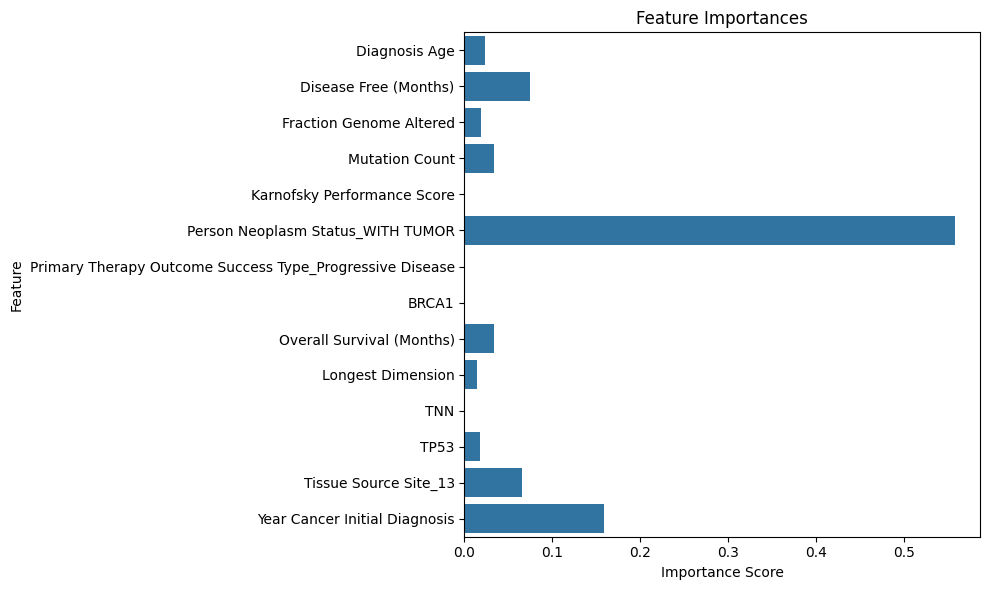

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from XGBoost
importances = model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
